<a href="https://colab.research.google.com/github/Ahmad860187/VIP2026/blob/main/beqaa_crop_mapping_2023.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Beqaa Crop Mapping 2023

This notebook/script replaces the earlier prototype with a more defensible
workflow for Beqaa agricultural crop-category mapping using matched 2023 labels
and 2023 Sentinel-2 imagery.

Key changes:
- uses the available Lebanon label raster for what it actually contains:
  crop categories, not crop species like corn or soybean;
- aligns labels explicitly to the Sentinel-2 reference grid before training;
- uses a spatial group split and capped per-class sampling;
- focuses on robust tabular baselines (Random Forest and LightGBM);
- separates training labels from the prediction mask;
- caches intermediate products and writes QA diagnostics.



In [1]:
RUN_INSTALLS = False

if RUN_INSTALLS:
    import subprocess
    import sys

    PACKAGES = [
        "earthengine-api",
        "rasterio",
        "shapely",
        "pyproj",
        "lightgbm",
        "scikit-learn",
        "matplotlib",
        "seaborn",
        "joblib",
    ]
    for pkg in PACKAGES:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])



In [2]:
import json
import math
import warnings
from collections import OrderedDict
from contextlib import ExitStack
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
import seaborn as sns
from rasterio.windows import Window, from_bounds
from rasterio.warp import reproject, Resampling
from shapely.geometry import box, mapping, shape
from shapely.ops import unary_union
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.utils.class_weight import compute_sample_weight

try:
    import lightgbm as lgb
except ImportError:
    lgb = None

warnings.filterwarnings("ignore")
np.random.seed(42)
print("Imports ready")
print("LightGBM available:", lgb is not None)



Imports ready
LightGBM available: True


In [3]:
PROJECT_SLUG = "beqaa_crop_mapping_2023"
EXPORT_FOLDER = "beqaa_crop_mapping_2023_exports"
GEE_PROJECT = "project-a1b10be0-abe1-4244-a3d"
TARGET_CRS = "EPSG:32636"
TARGET_RES = 10
YEAR = 2023

BEQAA_BBOX = {
    "west": 35.45,
    "south": 33.25,
    "east": 36.65,
    "north": 34.50,
}

MONTHS = OrderedDict(
    [
        ("Mar", ("2023-03-01", "2023-04-01")),
        ("Apr", ("2023-04-01", "2023-05-01")),
        ("May", ("2023-05-01", "2023-06-01")),
        ("Jun", ("2023-06-01", "2023-07-01")),
        ("Jul", ("2023-07-01", "2023-08-01")),
        ("Aug", ("2023-08-01", "2023-09-01")),
        ("Sep", ("2023-09-01", "2023-10-01")),
        ("Oct", ("2023-10-01", "2023-11-01")),
        ("Nov", ("2023-11-01", "2023-12-01")),
    ]
)

S2_BANDS = ["B2", "B3", "B4", "B5", "B6", "B7", "B8", "B8A", "B11", "B12"]
INDICES = ["NDVI", "EVI", "NDWI", "LSWI", "NDRE", "PSRI"]
EXPORT_BANDS = S2_BANDS + INDICES

CLASS_MAPPING = {
    7: "Olive plantation",
    8: "Field crops and grape field",
    10: "Cereals",
    11: "Citrus orchard",
    12: "Fruit trees orchard",
    16: "Banana",
}
CLASS_IDS = np.array(sorted(CLASS_MAPPING), dtype=np.uint8)
CLASS_COLORS = {
    7: "#7d6608",
    8: "#2ecc71",
    10: "#f5c242",
    11: "#f39c12",
    12: "#e74c3c",
    16: "#8e44ad",
}

TRAIN_CAP_PER_CLASS = 50000
VAL_CAP_PER_CLASS = 15000
TEST_CAP_PER_CLASS = 15000
SPATIAL_BLOCK_SIZE_PX = 384
BLOCK_ROWS = 256
# WorldCover class 40 alone misses orchard-like classes, but shrubland and
# grassland are too broad for final crop maps. Use tree cover + cropland and
# filter by confidence.
PREDICT_MASK_NAME = "tree_and_cropland"
PREDICT_WORLDCOVER_CLASSES = [10, 40]  # tree cover + cropland
APPLY_CONFIDENCE_FILTER = True
MIN_PREDICTION_CONFIDENCE = 0.60

DRIVE_ROOT = Path("/content/drive/MyDrive") / PROJECT_SLUG
DIRS = {
    "root": DRIVE_ROOT,
    "labels": DRIVE_ROOT / "labels",
    "rasters": DRIVE_ROOT / "rasters",
    "features": DRIVE_ROOT / "features",
    "models": DRIVE_ROOT / "models",
    "figures": DRIVE_ROOT / "figures",
    "results": DRIVE_ROOT / "results",
}

LABEL_FILENAME = "LCLU.CRC-LBN-2023.tif"
AOINAME = "beqaa_aoi.geojson"
ALIGNED_LABEL_PATH = DIRS["labels"] / f"aligned_labels_{YEAR}.tif"
ALIGNED_WORLDCOVER_PATH = DIRS["labels"] / "aligned_worldcover_2021.tif"
DATASET_CACHE = DIRS["features"] / f"sampled_dataset_{YEAR}.npz"
DATASET_SUMMARY_JSON = DIRS["features"] / f"sampled_dataset_{YEAR}_summary.json"
COMPARISON_CSV = DIRS["results"] / "model_comparison.csv"

print("Configuration ready")
print("Drive root:", DRIVE_ROOT)
print("Classes:", CLASS_MAPPING)



Configuration ready
Drive root: /content/drive/MyDrive/beqaa_crop_mapping_2023
Classes: {7: 'Olive plantation', 8: 'Field crops and grape field', 10: 'Cereals', 11: 'Citrus orchard', 12: 'Fruit trees orchard', 16: 'Banana'}


In [4]:
try:
    import google.colab  # type: ignore
    from google.colab import drive

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    drive.mount("/content/drive", force_remount=False)
    print("Google Drive mounted")
else:
    print("Not running in Colab. Google Drive and Earth Engine export cells will not work here.")

for path in DIRS.values():
    path.mkdir(parents=True, exist_ok=True)

EXPORT_SEARCH_DIRS = [DIRS["rasters"], Path("/content/drive/MyDrive") / EXPORT_FOLDER]
print("Export search dirs:")
for path in EXPORT_SEARCH_DIRS:
    print(" -", path)



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted
Export search dirs:
 - /content/drive/MyDrive/beqaa_crop_mapping_2023/rasters
 - /content/drive/MyDrive/beqaa_crop_mapping_2023_exports


## 1. Labels and AOI

This workflow expects the Lebanon crop-category label raster in
`labels/LCLU.CRC-LBN-2023.tif`. This 2023 label raster is intentionally
matched with 2023 Sentinel-2 imagery in this folder.
If it is not already in Google Drive, set `UPLOAD_LABEL_FROM_COMPUTER = True`
once and upload it.



In [5]:
UPLOAD_LABEL_FROM_COMPUTER = False

if UPLOAD_LABEL_FROM_COMPUTER and IN_COLAB:
    from google.colab import files

    uploaded = files.upload()
    for name, data in uploaded.items():
        dest = DIRS["labels"] / Path(name).name
        dest.write_bytes(data)
        print("Saved:", dest)



Using AOI from /content/drive/MyDrive/beqaa_crop_mapping_2023/labels/beqaa_boundary.geojson


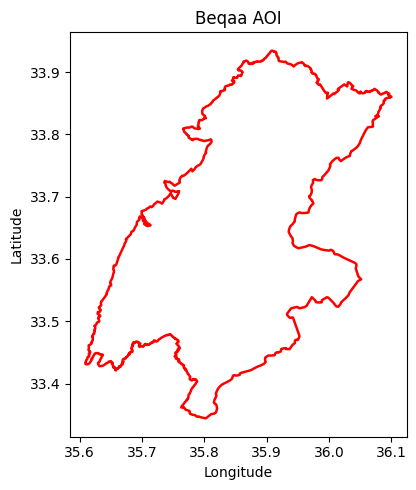

Saved canonical AOI to /content/drive/MyDrive/beqaa_crop_mapping_2023/labels/beqaa_aoi.geojson


In [6]:
def load_geojson_geometry(path):
    with open(path, "r", encoding="utf-8") as f:
        gj = json.load(f)

    if gj.get("type") == "FeatureCollection":
        geoms = [shape(feat["geometry"]) for feat in gj.get("features", []) if feat.get("geometry")]
        if not geoms:
            raise ValueError(f"No geometries found in {path}")
        geom = unary_union(geoms)
    elif gj.get("type") == "Feature":
        geom = shape(gj["geometry"])
    else:
        geom = shape(gj)

    return geom.buffer(0)


def write_geojson(path, geom):
    payload = {
        "type": "FeatureCollection",
        "features": [
            {
                "type": "Feature",
                "properties": {"name": "Beqaa"},
                "geometry": mapping(geom),
            }
        ],
    }
    with open(path, "w", encoding="utf-8") as f:
        json.dump(payload, f)


def plot_shapely_geometry(ax, geom, **kwargs):
    if geom.geom_type == "Polygon":
        x, y = geom.exterior.xy
        ax.plot(x, y, **kwargs)
        for ring in geom.interiors:
            xi, yi = ring.xy
            ax.plot(xi, yi, color=kwargs.get("color", "red"), linewidth=0.6)
    elif geom.geom_type == "MultiPolygon":
        for poly in geom.geoms:
            plot_shapely_geometry(ax, poly, **kwargs)
    else:
        raise ValueError(f"Unsupported geometry type: {geom.geom_type}")


def load_aoi_geometry():
    candidates = [
        DIRS["labels"] / "bekaa_boundary.geojson",
        DIRS["labels"] / "beqaa_boundary.geojson",
        DIRS["labels"] / AOINAME,
        Path("/content") / AOINAME,
    ]
    for path in candidates:
        if path.exists():
            print("Using AOI from", path)
            return load_geojson_geometry(path)

    print("No boundary file found. Falling back to configured bounding box.")
    return box(
        BEQAA_BBOX["west"],
        BEQAA_BBOX["south"],
        BEQAA_BBOX["east"],
        BEQAA_BBOX["north"],
    )


beqaa_geom = load_aoi_geometry()
canonical_aoi_path = DIRS["labels"] / AOINAME
write_geojson(canonical_aoi_path, beqaa_geom)

fig, ax = plt.subplots(figsize=(5, 5))
plot_shapely_geometry(ax, beqaa_geom, color="red", linewidth=1.8)
ax.set_title("Beqaa AOI")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect("equal")
plt.tight_layout()
plt.savefig(DIRS["figures"] / "aoi.png", dpi=150)
plt.show()
print("Saved canonical AOI to", canonical_aoi_path)



## 2. Earth Engine exports

This section exports three products:
- a constant reference grid raster at 10 m in UTM zone 36N;
- ESA WorldCover 2021 classes for the AOI;
- monthly Sentinel-2 composites for March-November 2023.

Exports go to a simple root-level Google Drive folder because Earth Engine
`toDrive` exports do not reliably support nested paths.



In [7]:
import ee


def ee_authenticate(project_id):
    if IN_COLAB:
        from google.colab import auth as colab_auth

        colab_auth.authenticate_user()
    ee.Initialize(project=project_id)
    print("Earth Engine ready with project", project_id)


def load_aoi_ee(path):
    with open(path, "r", encoding="utf-8") as f:
        gj = json.load(f)
    return ee.FeatureCollection(gj).geometry()


def add_cloud_probability(img):
    cloud_prob = ee.Image(img.get("cloud_mask")).select("probability")
    is_clear = cloud_prob.lt(40)
    scl = img.select("SCL")
    not_bad_scl = (
        scl.neq(3)
        .And(scl.neq(8))
        .And(scl.neq(9))
        .And(scl.neq(10))
        .And(scl.neq(11))
    )
    return img.updateMask(is_clear.And(not_bad_scl))


def add_indices(img):
    img = img.divide(10000)
    ndvi = img.normalizedDifference(["B8", "B4"]).rename("NDVI")
    evi = img.expression(
        "2.5 * ((nir - red) / (nir + 6 * red - 7.5 * blue + 1))",
        {"nir": img.select("B8"), "red": img.select("B4"), "blue": img.select("B2")},
    ).rename("EVI")
    ndwi = img.normalizedDifference(["B3", "B8"]).rename("NDWI")
    lswi = img.normalizedDifference(["B8", "B11"]).rename("LSWI")
    ndre = img.normalizedDifference(["B8A", "B5"]).rename("NDRE")
    psri = img.expression(
        "(red - blue) / rededge",
        {"red": img.select("B4"), "blue": img.select("B2"), "rededge": img.select("B6")},
    ).rename("PSRI")
    return img.addBands([ndvi, evi, ndwi, lswi, ndre, psri]).select(EXPORT_BANDS).toFloat()


def monthly_composite(aoi_ee, start_date, end_date):
    s2 = (
        ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
        .filterBounds(aoi_ee)
        .filterDate(start_date, end_date)
        .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 70))
    )
    clouds = (
        ee.ImageCollection("COPERNICUS/S2_CLOUD_PROBABILITY")
        .filterBounds(aoi_ee)
        .filterDate(start_date, end_date)
    )
    joined = ee.ImageCollection(
        ee.Join.saveFirst("cloud_mask").apply(
            primary=s2,
            secondary=clouds,
            condition=ee.Filter.equals(leftField="system:index", rightField="system:index"),
        )
    )
    processed = joined.map(add_cloud_probability).map(add_indices)
    count = processed.size()
    composite = ee.Image(
        ee.Algorithms.If(
            count.gt(0),
            processed.median().clip(aoi_ee),
            ee.Image.constant([0] * len(EXPORT_BANDS)).rename(EXPORT_BANDS).toFloat().clip(aoi_ee),
        )
    )
    return composite, count


def submit_drive_export(image, description, prefix, aoi_ee, scale=10, file_dimensions=None):
    params = dict(
        image=image,
        description=description,
        folder=EXPORT_FOLDER,
        fileNamePrefix=prefix,
        region=aoi_ee,
        scale=scale,
        crs=TARGET_CRS,
        maxPixels=int(1e13),
        fileFormat="GeoTIFF",
        skipEmptyTiles=True,
    )
    if file_dimensions is not None:
        params["fileDimensions"] = file_dimensions
    task = ee.batch.Export.image.toDrive(**params)
    task.start()
    return task


ee_authenticate(GEE_PROJECT)
aoi_ee = load_aoi_ee(canonical_aoi_path)
print("AOI EE type:", aoi_ee.type().getInfo())



Earth Engine ready with project project-a1b10be0-abe1-4244-a3d
AOI EE type: Polygon


In [8]:
SUBMIT_GEE_EXPORTS = False


def submit_all_exports(submit=False):
    submitted = {}
    if not submit:
        print("SUBMIT_GEE_EXPORTS is False. No export tasks were started.")
        return submitted

    ref_img = ee.Image.constant(1).rename("refgrid").toByte().clip(aoi_ee)
    ref_task = submit_drive_export(
        ref_img,
        f"beqaa_refgrid_{YEAR}",
        f"beqaa_refgrid_{YEAR}",
        aoi_ee,
        scale=TARGET_RES,
        file_dimensions=None,
    )
    submitted["refgrid"] = ref_task.id
    print("Submitted reference grid:", ref_task.id)

    wc_img = ee.ImageCollection("ESA/WorldCover/v200").first().rename("worldcover").clip(aoi_ee).toByte()
    wc_task = submit_drive_export(
        wc_img,
        "beqaa_worldcover_2021",
        "beqaa_worldcover_2021",
        aoi_ee,
        scale=10,
        file_dimensions=None,
    )
    submitted["worldcover"] = wc_task.id
    print("Submitted WorldCover:", wc_task.id)

    for month, (start_date, end_date) in MONTHS.items():
        comp, count = monthly_composite(aoi_ee, start_date, end_date)
        task = submit_drive_export(
            comp,
            f"beqaa_s2_{month}_{YEAR}",
            f"beqaa_s2_{month}_{YEAR}",
            aoi_ee,
            scale=TARGET_RES,
            file_dimensions=8192,
        )
        submitted[month] = task.id
        print(f"Submitted {month}: task={task.id} images={count.getInfo()}")

    return submitted


submitted = submit_all_exports(SUBMIT_GEE_EXPORTS)
if submitted:
    print("Monitor tasks at https://code.earthengine.google.com/tasks")



SUBMIT_GEE_EXPORTS is False. No export tasks were started.


In [9]:
def find_raster_files(prefix):
    hits = []
    seen = set()
    for root in EXPORT_SEARCH_DIRS:
        if not root.exists():
            continue
        for path in sorted(root.glob(f"{prefix}*.tif")):
            key = str(path.resolve())
            if key not in seen:
                hits.append(path)
                seen.add(key)
    return hits


def find_single_raster(prefix):
    hits = find_raster_files(prefix)
    if not hits:
        return None
    exact = [p for p in hits if p.name == f"{prefix}.tif"]
    return exact[0] if exact else hits[0]


def tile_key(path, prefix):
    name = path.name
    exact = f"{prefix}.tif"
    if name == exact:
        return "full"
    if name.startswith(prefix + "-") and name.endswith(".tif"):
        return name[len(prefix) + 1 : -4]
    raise ValueError(f"Unexpected tile name: {name}")


def build_tile_index(month_names):
    tile_index = {}
    for month in month_names:
        prefix = f"beqaa_s2_{month}_{YEAR}"
        hits = find_raster_files(prefix)
        if not hits:
            raise FileNotFoundError(f"No exported rasters found for {prefix}")
        tile_index[month] = {tile_key(path, prefix): path for path in hits}
    return tile_index


def tile_global_window(tile_path, ref_transform):
    with rasterio.open(tile_path) as src:
        win = from_bounds(*src.bounds, transform=ref_transform)
        return Window(
            col_off=int(round(win.col_off)),
            row_off=int(round(win.row_off)),
            width=src.width,
            height=src.height,
        )


def align_to_reference(src_path, ref_path, out_path, resampling):
    with rasterio.open(ref_path) as ref:
        profile = ref.profile.copy()
        dst = np.zeros((ref.height, ref.width), dtype=np.uint8)
        with rasterio.open(src_path) as src:
            reproject(
                source=rasterio.band(src, 1),
                destination=dst,
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=ref.transform,
                dst_crs=ref.crs,
                resampling=resampling,
                dst_nodata=0,
            )

    profile.update(count=1, dtype="uint8", nodata=0, compress="lzw")
    with rasterio.open(out_path, "w", **profile) as dst_file:
        dst_file.write(dst, 1)
    return out_path


reference_grid_path = find_single_raster(f"beqaa_refgrid_{YEAR}")
if reference_grid_path is None:
    raise FileNotFoundError(
        "Reference grid export not found. Run the Earth Engine export cell, wait for completion, then rerun."
    )

worldcover_src_path = find_single_raster("beqaa_worldcover_2021")
label_path = None
for candidate in [DIRS["labels"] / LABEL_FILENAME, Path("/content") / LABEL_FILENAME]:
    if candidate.exists():
        label_path = candidate
        break
if label_path is None:
    raise FileNotFoundError(f"Label raster {LABEL_FILENAME} not found in {DIRS['labels']} or /content.")

if (not ALIGNED_LABEL_PATH.exists()) or (ALIGNED_LABEL_PATH.stat().st_mtime < label_path.stat().st_mtime):
    align_to_reference(label_path, reference_grid_path, ALIGNED_LABEL_PATH, Resampling.nearest)
    print("Aligned labels saved to", ALIGNED_LABEL_PATH)
else:
    print("Using cached aligned labels", ALIGNED_LABEL_PATH)

if worldcover_src_path is not None:
    if (not ALIGNED_WORLDCOVER_PATH.exists()) or (
        ALIGNED_WORLDCOVER_PATH.stat().st_mtime < worldcover_src_path.stat().st_mtime
    ):
        align_to_reference(worldcover_src_path, reference_grid_path, ALIGNED_WORLDCOVER_PATH, Resampling.nearest)
        print("Aligned WorldCover saved to", ALIGNED_WORLDCOVER_PATH)
    else:
        print("Using cached aligned WorldCover", ALIGNED_WORLDCOVER_PATH)
else:
    print("WorldCover export not found yet. Prediction map step will be unavailable until it exists.")



Aligned labels saved to /content/drive/MyDrive/beqaa_crop_mapping_2023/labels/aligned_labels_2023.tif
Aligned WorldCover saved to /content/drive/MyDrive/beqaa_crop_mapping_2023/labels/aligned_worldcover_2021.tif


Aligned label counts:
 - 7: Olive plantation: 1,064,349
 - 8: Field crops and grape field: 1,643,894
 - 10: Cereals: 1,401,431
 - 11: Citrus orchard: 114,986
 - 12: Fruit trees orchard: 607,995
 - 16: Banana: 97,535
Label coverage inside WorldCover cropland only [40]: 0.433
Label coverage inside Selected prediction mask [10,40]: 0.546
If this remains low, review the AOI, WorldCover alignment, or use a project-specific agriculture mask.


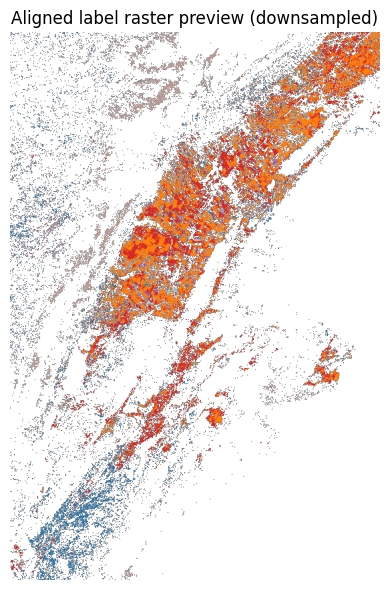

In [10]:
with rasterio.open(reference_grid_path) as ref:
    REF_PROFILE = ref.profile.copy()
    REF_TRANSFORM = ref.transform
    REF_CRS = ref.crs
    REF_HEIGHT = ref.height
    REF_WIDTH = ref.width

with rasterio.open(ALIGNED_LABEL_PATH) as src:
    labels_aligned = src.read(1)

label_counts = {int(cid): int((labels_aligned == cid).sum()) for cid in CLASS_IDS}
print("Aligned label counts:")
for cid in CLASS_IDS:
    print(f" - {cid}: {CLASS_MAPPING[int(cid)]}: {label_counts[int(cid)]:,}")

if ALIGNED_WORLDCOVER_PATH.exists():
    with rasterio.open(ALIGNED_WORLDCOVER_PATH) as src:
        wc = src.read(1)
    labeled_mask = np.isin(labels_aligned, CLASS_IDS)

    mask_diagnostics = {
        "WorldCover cropland only [40]": [40],
        "Selected prediction mask [10,40]": PREDICT_WORLDCOVER_CLASSES,
    }
    for mask_name, wc_classes in mask_diagnostics.items():
        candidate_mask = np.isin(wc, wc_classes)
        coverage = float(((candidate_mask) & labeled_mask).sum() / max(labeled_mask.sum(), 1))
        print(f"Label coverage inside {mask_name}: {coverage:.3f}")

    selected_candidate_mask = np.isin(wc, PREDICT_WORLDCOVER_CLASSES)
    selected_coverage = float(((selected_candidate_mask) & labeled_mask).sum() / max(labeled_mask.sum(), 1))
    if selected_coverage < 0.80:
        print("Warning: even the selected independent prediction mask misses many labeled crop pixels.")
        print("If this remains low, review the AOI, WorldCover alignment, or use a project-specific agriculture mask.")

preview = labels_aligned.copy().astype(np.float32)
preview[preview == 0] = np.nan
fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(preview[::8, ::8], cmap="tab20")
ax.set_title("Aligned label raster preview (downsampled)")
ax.set_axis_off()
plt.tight_layout()
plt.savefig(DIRS["figures"] / "aligned_labels_preview.png", dpi=150)
plt.show()



## 3. Spatial sampling and feature extraction

Instead of extracting every labeled pixel into RAM, this workflow:
- aligns the labels first;
- creates a spatial group split;
- samples a capped number of pixels per class and split;
- extracts features only for those sampled pixels.



In [11]:
month_names = list(MONTHS.keys())
TILE_INDEX = build_tile_index(month_names)
base_keys = set(TILE_INDEX[month_names[0]].keys())
for month in month_names[1:]:
    if set(TILE_INDEX[month].keys()) != base_keys:
        raise RuntimeError(f"Tile mismatch between {month_names[0]} and {month}")
TILE_KEYS = sorted(base_keys)
print("Months ready:", month_names)
print("Tile keys:", TILE_KEYS)
print("Reference shape:", (REF_HEIGHT, REF_WIDTH))
print("Bands per month:", len(EXPORT_BANDS))



Months ready: ['Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov']
Tile keys: ['full']
Reference shape: (6576, 4429)
Bands per month: 16


In [12]:
def create_sample_masks(labels, block_size_px, seed=42):
    rng = np.random.default_rng(seed)
    n_block_cols = int(math.ceil(labels.shape[1] / block_size_px))
    class_mask = np.zeros_like(labels, dtype=np.uint8)
    split_mask = np.zeros_like(labels, dtype=np.uint8)  # 0=unused, 1=train, 2=val, 3=test
    summary = {}

    for cid in CLASS_IDS:
        rr, cc = np.where(labels == cid)
        if len(rr) == 0:
            continue

        groups = (rr // block_size_px) * n_block_cols + (cc // block_size_px)
        unique_groups = np.unique(groups)
        unique_groups = rng.permutation(unique_groups)

        n_train = max(1, int(round(0.70 * len(unique_groups))))
        n_val = max(1, int(round(0.15 * len(unique_groups))))
        train_groups = set(unique_groups[:n_train])
        val_groups = set(unique_groups[n_train : n_train + n_val])
        test_groups = set(unique_groups[n_train + n_val :])

        split_codes = np.zeros(len(rr), dtype=np.uint8)
        split_codes[np.isin(groups, list(train_groups))] = 1
        split_codes[np.isin(groups, list(val_groups))] = 2
        split_codes[np.isin(groups, list(test_groups))] = 3

        chosen = {
            1: np.flatnonzero(split_codes == 1),
            2: np.flatnonzero(split_codes == 2),
            3: np.flatnonzero(split_codes == 3),
        }
        caps = {1: TRAIN_CAP_PER_CLASS, 2: VAL_CAP_PER_CLASS, 3: TEST_CAP_PER_CLASS}

        summary[int(cid)] = {}
        for split_code, idx in chosen.items():
            if len(idx) > caps[split_code]:
                idx = rng.choice(idx, size=caps[split_code], replace=False)
            class_mask[rr[idx], cc[idx]] = cid
            split_mask[rr[idx], cc[idx]] = split_code
            split_name = {1: "train", 2: "val", 3: "test"}[split_code]
            summary[int(cid)][split_name] = int(len(idx))

    return class_mask, split_mask, summary


def read_block(src, window):
    arr = src.read(window=window).astype(np.float32)
    if src.nodata is not None:
        arr[arr == src.nodata] = np.nan
    return arr


def compute_pheno_features(month_vectors):
    ndvi_idx = EXPORT_BANDS.index("NDVI")
    evi_idx = EXPORT_BANDS.index("EVI")
    ndre_idx = EXPORT_BANDS.index("NDRE")
    lswi_idx = EXPORT_BANDS.index("LSWI")

    ndvi_ts = np.stack([vec[:, ndvi_idx] for vec in month_vectors], axis=1)
    evi_ts = np.stack([vec[:, evi_idx] for vec in month_vectors], axis=1)
    ndre_ts = np.stack([vec[:, ndre_idx] for vec in month_vectors], axis=1)
    lswi_ts = np.stack([vec[:, lswi_idx] for vec in month_vectors], axis=1)

    ndvi_filled = np.where(np.isfinite(ndvi_ts), ndvi_ts, -9999)
    if ndvi_ts.shape[1] > 1:
        ndvi_diff = np.diff(np.nan_to_num(ndvi_ts, nan=0.0), axis=1)
    else:
        ndvi_diff = np.zeros((len(ndvi_ts), 1), dtype=np.float32)

    features = np.column_stack(
        [
            np.nanmax(ndvi_ts, axis=1),
            np.nanmin(ndvi_ts, axis=1),
            np.nanmax(ndvi_ts, axis=1) - np.nanmin(ndvi_ts, axis=1),
            np.nanmean(ndvi_ts, axis=1),
            np.nanstd(ndvi_ts, axis=1),
            np.nanargmax(ndvi_filled, axis=1).astype(np.float32),
            np.nanmax(ndvi_diff, axis=1),
            np.nanmin(ndvi_diff, axis=1),
            np.nanmax(evi_ts, axis=1),
            np.nanmean(evi_ts, axis=1),
            np.nanmax(ndre_ts, axis=1),
            np.nanmean(ndre_ts, axis=1),
            np.nanmean(lswi_ts, axis=1),
        ]
    ).astype(np.float32)

    names = [
        "NDVI_max",
        "NDVI_min",
        "NDVI_amp",
        "NDVI_mean",
        "NDVI_std",
        "NDVI_peak_month_idx",
        "NDVI_greenup_slope",
        "NDVI_senescence_slope",
        "EVI_max",
        "EVI_mean",
        "NDRE_max",
        "NDRE_mean",
        "LSWI_mean",
    ]
    return features, names


def extract_sampled_feature_dataset(class_mask, split_mask):
    buckets = {
        1: {"X": [], "y": [], "coords": []},
        2: {"X": [], "y": [], "coords": []},
        3: {"X": [], "y": [], "coords": []},
    }

    raw_feature_names = [f"{band}_{month}" for month in month_names for band in EXPORT_BANDS]
    pheno_names = None

    for tile_name in TILE_KEYS:
        month_paths = {month: TILE_INDEX[month][tile_name] for month in month_names}
        ref_tile = month_paths[month_names[0]]
        base_window = tile_global_window(ref_tile, REF_TRANSFORM)

        with ExitStack() as stack:
            month_srcs = {month: stack.enter_context(rasterio.open(path)) for month, path in month_paths.items()}
            tile_h = month_srcs[month_names[0]].height
            tile_w = month_srcs[month_names[0]].width

            for row0 in range(0, tile_h, BLOCK_ROWS):
                h = min(BLOCK_ROWS, tile_h - row0)
                tile_window = Window(0, row0, tile_w, h)
                global_window = Window(
                    col_off=int(base_window.col_off),
                    row_off=int(base_window.row_off) + row0,
                    width=tile_w,
                    height=h,
                )

                r0 = int(global_window.row_off)
                r1 = r0 + h
                c0 = int(global_window.col_off)
                c1 = c0 + tile_w

                y_block = class_mask[r0:r1, c0:c1]
                if not np.any(y_block > 0):
                    continue

                rr, cc = np.where(y_block > 0)
                split_codes = split_mask[r0:r1, c0:c1][rr, cc]
                coords = np.column_stack([rr + r0, cc + c0]).astype(np.int32)
                y_vals = y_block[rr, cc].astype(np.uint8)

                month_vectors = []
                for month in month_names:
                    arr = read_block(month_srcs[month], tile_window)
                    month_vectors.append(arr[:, rr, cc].T.astype(np.float32))

                X_raw = np.hstack(month_vectors).astype(np.float32)
                pheno, pheno_names = compute_pheno_features(month_vectors)
                X_block = np.hstack([X_raw, pheno]).astype(np.float32)
                X_block[~np.isfinite(X_block)] = np.nan

                for split_code in (1, 2, 3):
                    take = split_codes == split_code
                    if not np.any(take):
                        continue
                    buckets[split_code]["X"].append(X_block[take])
                    buckets[split_code]["y"].append(y_vals[take])
                    buckets[split_code]["coords"].append(coords[take])

    feature_names = raw_feature_names + pheno_names
    out = {}
    split_names = {1: "train", 2: "val", 3: "test"}
    for split_code, split_name in split_names.items():
        if not buckets[split_code]["X"]:
            raise RuntimeError(f"No sampled pixels were extracted for split '{split_name}'.")
        out[f"X_{split_name}"] = np.vstack(buckets[split_code]["X"]).astype(np.float32)
        out[f"y_{split_name}"] = np.concatenate(buckets[split_code]["y"]).astype(np.uint8)
        out[f"coords_{split_name}"] = np.vstack(buckets[split_code]["coords"]).astype(np.int32)
    out["feature_names"] = np.array(feature_names, dtype=object)
    out["classes"] = CLASS_IDS.astype(np.uint8)
    return out


FORCE_REBUILD_DATASET = False

if DATASET_CACHE.exists() and not FORCE_REBUILD_DATASET:
    cache = np.load(DATASET_CACHE, allow_pickle=True)
    dataset = {key: cache[key] for key in cache.files}
    sample_summary = json.loads(DATASET_SUMMARY_JSON.read_text(encoding="utf-8"))
    print("Loaded cached sampled dataset from", DATASET_CACHE)
else:
    sampled_label_mask, sampled_split_mask, sample_summary = create_sample_masks(
        labels_aligned,
        block_size_px=SPATIAL_BLOCK_SIZE_PX,
        seed=42,
    )
    dataset = extract_sampled_feature_dataset(sampled_label_mask, sampled_split_mask)
    np.savez_compressed(DATASET_CACHE, **dataset)
    DATASET_SUMMARY_JSON.write_text(json.dumps(sample_summary, indent=2), encoding="utf-8")
    print("Built and cached sampled dataset at", DATASET_CACHE)

print("Sample summary:")
for cid in CLASS_IDS:
    cid = int(cid)
    print(cid, CLASS_MAPPING[cid], sample_summary.get(str(cid), sample_summary.get(cid, {})))

for split_name in ["train", "val", "test"]:
    print(split_name, dataset[f"X_{split_name}"].shape, dataset[f"y_{split_name}"].shape)



Built and cached sampled dataset at /content/drive/MyDrive/beqaa_crop_mapping_2023/features/sampled_dataset_2023.npz
Sample summary:
7 Olive plantation {'train': 50000, 'val': 15000, 'test': 15000}
8 Field crops and grape field {'train': 50000, 'val': 15000, 'test': 15000}
10 Cereals {'train': 50000, 'val': 15000, 'test': 15000}
11 Citrus orchard {'train': 50000, 'val': 15000, 'test': 9386}
12 Fruit trees orchard {'train': 50000, 'val': 15000, 'test': 15000}
16 Banana {'train': 50000, 'val': 15000, 'test': 14157}
train (300000, 157) (300000,)
val (90000, 157) (90000,)
test (83543, 157) (83543,)


In [13]:
feature_names = dataset["feature_names"].tolist()
classes = dataset["classes"].astype(np.uint8)

imputer = SimpleImputer(strategy="median")
X_train = imputer.fit_transform(dataset["X_train"])
X_val = imputer.transform(dataset["X_val"])
X_test = imputer.transform(dataset["X_test"])
y_train = dataset["y_train"].astype(np.uint8)
y_val = dataset["y_val"].astype(np.uint8)
y_test = dataset["y_test"].astype(np.uint8)

joblib.dump(imputer, DIRS["models"] / "imputer.joblib")
print("Saved imputer to", DIRS["models"] / "imputer.joblib")



Saved imputer to /content/drive/MyDrive/beqaa_crop_mapping_2023/models/imputer.joblib


## 4. Train models

The main model is LightGBM because the data are tabular, multi-temporal,
and medium-dimensional. A Random Forest is kept as a baseline.



Random Forest val macro F1: 0.5229
Random Forest accuracy     : 0.4704
Random Forest macro F1     : 0.4371
Random Forest weighted F1  : 0.4467
                             precision    recall  f1-score   support

           Olive plantation       0.40      0.92      0.56     15000
Field crops and grape field       0.52      0.55      0.53     15000
                    Cereals       0.64      0.52      0.58     15000
             Citrus orchard       0.34      0.30      0.32      9386
        Fruit trees orchard       0.69      0.23      0.35     15000
                     Banana       0.41      0.23      0.29     14157

                   accuracy                           0.47     83543
                  macro avg       0.50      0.46      0.44     83543
               weighted avg       0.51      0.47      0.45     83543



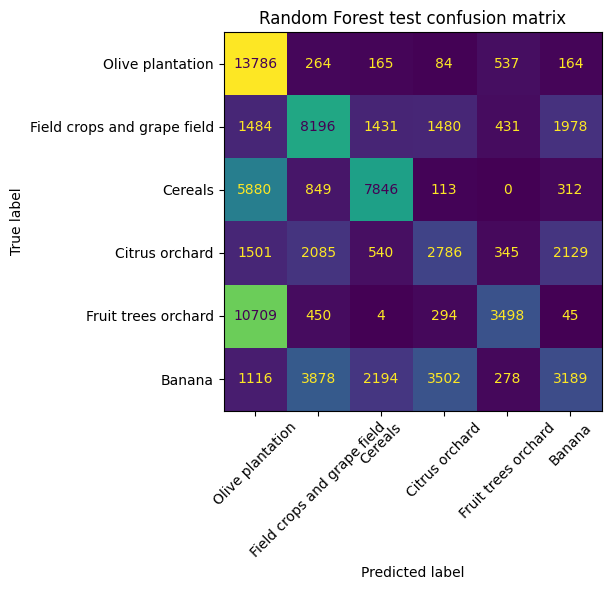

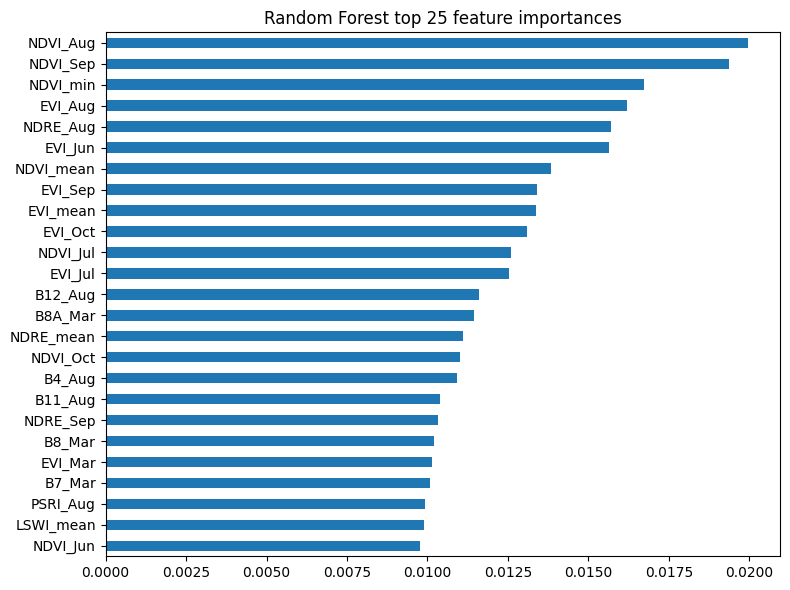

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.146937 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 39789
[LightGBM] [Info] Number of data points in the train set: 300000, number of used features: 157
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
LightGBM val macro F1: 0.6123
LightGBM accuracy     : 0.5083
LightGBM macro F1     : 0.4890
LightGBM weighted F1  : 0.4965
                             precision    recall  f1-score   support

           Olive plantation       0.77      0.32      0.45     15000
Field crops and grape field       0.56      0.51      0.53     15000
                    Cereals       0.68      0.52     

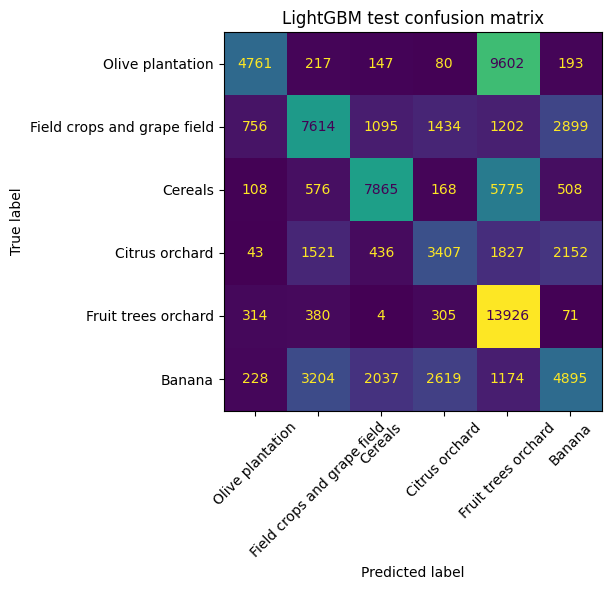

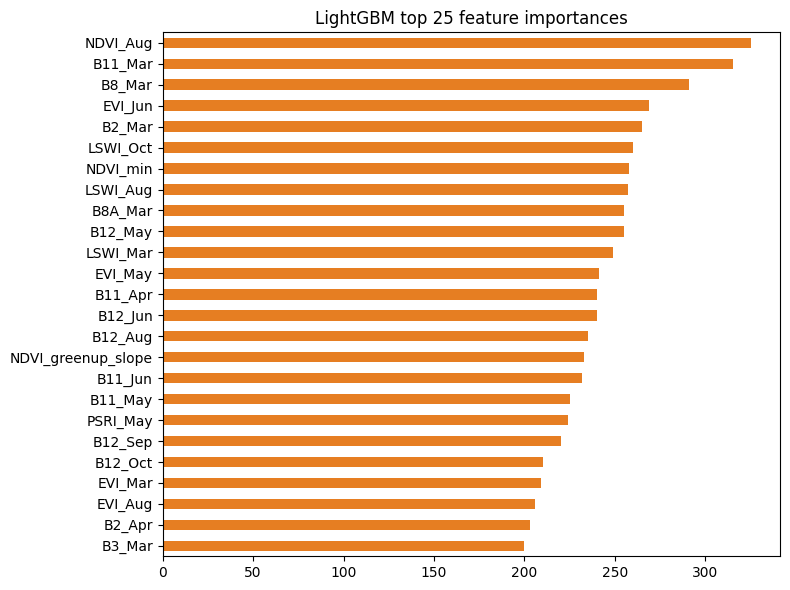

In [14]:
RESULTS = {}
MODELS = {}


def evaluate_predictions(name, y_true, y_pred, class_ids, fig_name):
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    weighted_f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    per_class_f1 = f1_score(y_true, y_pred, average=None, labels=class_ids, zero_division=0)

    print(f"{name} accuracy     : {acc:.4f}")
    print(f"{name} macro F1     : {macro_f1:.4f}")
    print(f"{name} weighted F1  : {weighted_f1:.4f}")
    print(
        classification_report(
            y_true,
            y_pred,
            labels=class_ids,
            target_names=[CLASS_MAPPING[int(cid)] for cid in class_ids],
            zero_division=0,
        )
    )

    cm = confusion_matrix(y_true, y_pred, labels=class_ids)
    fig, ax = plt.subplots(figsize=(7, 6))
    ConfusionMatrixDisplay(cm, display_labels=[CLASS_MAPPING[int(cid)] for cid in class_ids]).plot(
        ax=ax,
        colorbar=False,
        xticks_rotation=45,
    )
    ax.set_title(f"{name} test confusion matrix")
    plt.tight_layout()
    plt.savefig(DIRS["figures"] / fig_name, dpi=150)
    plt.show()

    return {
        "accuracy": float(acc),
        "macro_f1": float(macro_f1),
        "weighted_f1": float(weighted_f1),
        "per_class_f1": {int(cid): float(score) for cid, score in zip(class_ids, per_class_f1)},
    }


def train_random_forest(max_train_rows=150000):
    rng = np.random.default_rng(42)
    if len(X_train) > max_train_rows:
        idx = rng.choice(len(X_train), size=max_train_rows, replace=False)
        X_fit = X_train[idx]
        y_fit = y_train[idx]
    else:
        X_fit = X_train
        y_fit = y_train

    model = RandomForestClassifier(
        n_estimators=250,
        max_depth=None,
        min_samples_leaf=2,
        max_features="sqrt",
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=42,
    )
    model.fit(X_fit, y_fit)

    val_pred = model.predict(X_val)
    val_f1 = f1_score(y_val, val_pred, average="macro", zero_division=0)
    print("Random Forest val macro F1:", round(float(val_f1), 4))

    test_pred = model.predict(X_test)
    metrics = evaluate_predictions("Random Forest", y_test, test_pred, classes, "rf_confusion_matrix.png")
    metrics["val_macro_f1"] = float(val_f1)

    importances = pd.Series(model.feature_importances_, index=feature_names).nlargest(25)
    fig, ax = plt.subplots(figsize=(8, 6))
    importances.sort_values().plot(kind="barh", ax=ax)
    ax.set_title("Random Forest top 25 feature importances")
    plt.tight_layout()
    plt.savefig(DIRS["figures"] / "rf_feature_importance.png", dpi=150)
    plt.show()

    joblib.dump(model, DIRS["models"] / "random_forest.joblib")
    RESULTS["RandomForest"] = metrics
    MODELS["RandomForest"] = model


def train_lightgbm_model():
    if lgb is None:
        print("LightGBM is not installed. Skipping LightGBM.")
        return

    sample_weight = compute_sample_weight(class_weight="balanced", y=y_train)
    model = lgb.LGBMClassifier(
        objective="multiclass",
        n_estimators=1200,
        learning_rate=0.05,
        num_leaves=63,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
    )
    model.fit(
        X_train,
        y_train,
        sample_weight=sample_weight,
        eval_set=[(X_val, y_val)],
        eval_metric="multi_logloss",
        callbacks=[lgb.early_stopping(50, verbose=False)],
    )

    val_pred = model.predict(X_val)
    val_f1 = f1_score(y_val, val_pred, average="macro", zero_division=0)
    print("LightGBM val macro F1:", round(float(val_f1), 4))

    test_pred = model.predict(X_test)
    metrics = evaluate_predictions("LightGBM", y_test, test_pred, classes, "lgbm_confusion_matrix.png")
    metrics["val_macro_f1"] = float(val_f1)

    importances = pd.Series(model.feature_importances_, index=feature_names).nlargest(25)
    fig, ax = plt.subplots(figsize=(8, 6))
    importances.sort_values().plot(kind="barh", ax=ax, color="#e67e22")
    ax.set_title("LightGBM top 25 feature importances")
    plt.tight_layout()
    plt.savefig(DIRS["figures"] / "lgbm_feature_importance.png", dpi=150)
    plt.show()

    joblib.dump(model, DIRS["models"] / "lightgbm.joblib")
    RESULTS["LightGBM"] = metrics
    MODELS["LightGBM"] = model


train_random_forest()
train_lightgbm_model()



In [15]:
if not RESULTS:
    raise RuntimeError("No trained models are available.")

comparison = pd.DataFrame(RESULTS).T[["accuracy", "macro_f1", "weighted_f1", "val_macro_f1"]]
comparison = comparison.sort_values("val_macro_f1", ascending=False)
comparison.to_csv(COMPARISON_CSV, index=True)
print(comparison)
print("Saved model comparison to", COMPARISON_CSV)

best_model_name = comparison.index[0]
best_model = MODELS[best_model_name]
joblib.dump(best_model, DIRS["models"] / "best_model.joblib")
(DIRS["models"] / "best_model_name.txt").write_text(best_model_name, encoding="utf-8")
print("Best model:", best_model_name)



              accuracy  macro_f1 weighted_f1 val_macro_f1
LightGBM      0.508337  0.489023     0.49653     0.612338
RandomForest  0.470428  0.437077    0.446709     0.522936
Saved model comparison to /content/drive/MyDrive/beqaa_crop_mapping_2023/results/model_comparison.csv
Best model: LightGBM


## 5. Prediction map

The map step predicts only over an independent candidate agriculture mask
derived from WorldCover classes. The default uses tree cover + cropland:
`PREDICT_WORLDCOVER_CLASSES = [10, 40]`.



Saved prediction map to /content/drive/MyDrive/beqaa_crop_mapping_2023/results/beqaa_crop_map_2023.tif
Saved uncertainty map to /content/drive/MyDrive/beqaa_crop_mapping_2023/results/beqaa_uncertainty_2023.tif
Saved predicted area table to /content/drive/MyDrive/beqaa_crop_mapping_2023/results/predicted_area_by_class_2023.csv
   class_id                   class_name   pixels   area_ha
0         7             Olive plantation   387785   3877.85
1         8  Field crops and grape field   711710   7117.10
2        10                      Cereals  1049409  10494.09
3        11               Citrus orchard   257310   2573.10
4        12          Fruit trees orchard   243490   2434.90
5        16                       Banana   141184   1411.84


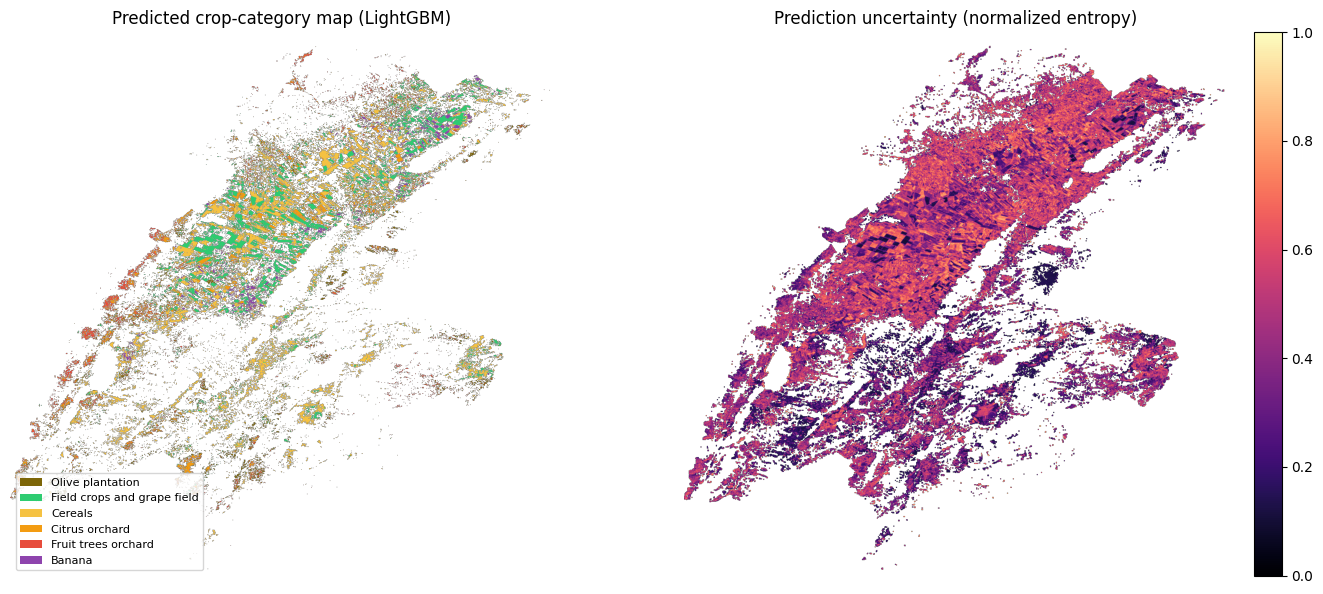

In [16]:
RUN_PREDICTION = True


def predict_block_probabilities(model, X_block):
    if hasattr(model, "predict_proba"):
        raw_probs = model.predict_proba(X_block)
        source_classes = np.array(getattr(model, "classes_", classes))
        aligned = np.zeros((raw_probs.shape[0], len(classes)), dtype=np.float32)
        for source_idx, class_id in enumerate(source_classes):
            target_idx = np.where(classes == class_id)[0]
            if len(target_idx):
                aligned[:, target_idx[0]] = raw_probs[:, source_idx]
        return aligned
    preds = model.predict(X_block)
    out = np.zeros((len(preds), len(classes)), dtype=np.float32)
    for idx, cid in enumerate(classes):
        out[:, idx] = (preds == cid).astype(np.float32)
    return out


if RUN_PREDICTION:
    if not ALIGNED_WORLDCOVER_PATH.exists():
        raise FileNotFoundError("Aligned WorldCover is required for prediction. Export and align it first.")

    pred_path = DIRS["results"] / f"beqaa_crop_map_{YEAR}.tif"
    unc_path = DIRS["results"] / f"beqaa_uncertainty_{YEAR}.tif"

    pred_profile = REF_PROFILE.copy()
    pred_profile.update(count=1, dtype="uint8", nodata=0, compress="lzw")
    unc_profile = REF_PROFILE.copy()
    unc_profile.update(count=1, dtype="float32", nodata=np.float32(-1), compress="lzw")

    def month_block_features(month_srcs, tile_window, rr, cc):
        month_vectors = []
        for month in month_names:
            arr = read_block(month_srcs[month], tile_window)
            month_vectors.append(arr[:, rr, cc].T.astype(np.float32))
        X_raw = np.hstack(month_vectors).astype(np.float32)
        pheno, _ = compute_pheno_features(month_vectors)
        X_block = np.hstack([X_raw, pheno]).astype(np.float32)
        X_block[~np.isfinite(X_block)] = np.nan
        return X_block

    with rasterio.open(ALIGNED_WORLDCOVER_PATH) as wc_src, rasterio.open(
        pred_path, "w", **pred_profile
    ) as pred_dst, rasterio.open(unc_path, "w", **unc_profile) as unc_dst:
        for tile_name in TILE_KEYS:
            month_paths = {month: TILE_INDEX[month][tile_name] for month in month_names}
            ref_tile = month_paths[month_names[0]]
            base_window = tile_global_window(ref_tile, REF_TRANSFORM)

            with ExitStack() as stack:
                month_srcs = {month: stack.enter_context(rasterio.open(path)) for month, path in month_paths.items()}
                tile_h = month_srcs[month_names[0]].height
                tile_w = month_srcs[month_names[0]].width

                for row0 in range(0, tile_h, BLOCK_ROWS):
                    h = min(BLOCK_ROWS, tile_h - row0)
                    tile_window = Window(0, row0, tile_w, h)
                    global_window = Window(
                        col_off=int(base_window.col_off),
                        row_off=int(base_window.row_off) + row0,
                        width=tile_w,
                        height=h,
                    )

                    candidate = wc_src.read(1, window=global_window)
                    candidate = np.isin(candidate, PREDICT_WORLDCOVER_CLASSES)
                    pred_block = np.zeros((h, tile_w), dtype=np.uint8)
                    unc_block = np.full((h, tile_w), np.float32(-1), dtype=np.float32)

                    if np.any(candidate):
                        rr, cc = np.where(candidate)
                        X_block = month_block_features(month_srcs, tile_window, rr, cc)
                        X_block = imputer.transform(X_block)
                        probs = predict_block_probabilities(best_model, X_block)
                        pred_ids = classes[np.argmax(probs, axis=1)]
                        max_probs = np.max(probs, axis=1)
                        entropy = -(probs * np.log(np.clip(probs, 1e-8, 1.0))).sum(axis=1) / math.log(len(classes))
                        unc_block[rr, cc] = entropy.astype(np.float32)
                        if APPLY_CONFIDENCE_FILTER:
                            confident = max_probs >= MIN_PREDICTION_CONFIDENCE
                            pred_block[rr[confident], cc[confident]] = pred_ids[confident].astype(np.uint8)
                        else:
                            pred_block[rr, cc] = pred_ids.astype(np.uint8)

                    pred_dst.write(pred_block, 1, window=global_window)
                    unc_dst.write(unc_block, 1, window=global_window)

    print("Saved prediction map to", pred_path)
    print("Saved uncertainty map to", unc_path)

    counts = {int(cid): 0 for cid in classes}
    with rasterio.open(pred_path) as src:
        pixel_area_ha = abs(src.transform.a * src.transform.e) / 10000.0
        for _, window in src.block_windows(1):
            arr = src.read(1, window=window)
            block_counts = np.bincount(arr.ravel(), minlength=256)
            for cid in classes:
                counts[int(cid)] += int(block_counts[int(cid)])

    area_rows = []
    for cid in classes:
        cid_int = int(cid)
        area_rows.append(
            {
                "class_id": cid_int,
                "class_name": CLASS_MAPPING[cid_int],
                "pixels": counts[cid_int],
                "area_ha": counts[cid_int] * pixel_area_ha,
            }
        )
    area_df = pd.DataFrame(area_rows)
    area_csv = DIRS["results"] / f"predicted_area_by_class_{YEAR}.csv"
    area_df.to_csv(area_csv, index=False)
    print("Saved predicted area table to", area_csv)
    print(area_df)

    with rasterio.open(pred_path) as src:
        pred_preview = src.read(1, out_shape=(min(1024, src.height), min(1024, src.width)), resampling=Resampling.nearest)
    with rasterio.open(unc_path) as src:
        unc_preview = src.read(1, out_shape=(min(1024, src.height), min(1024, src.width)), resampling=Resampling.bilinear)

    from matplotlib.colors import BoundaryNorm, ListedColormap
    from matplotlib.patches import Patch

    class_values = classes.astype(int).tolist()
    ordered_colors = [CLASS_COLORS[cid] for cid in class_values]
    cmap = ListedColormap(ordered_colors)
    bounds = [class_values[0] - 0.5] + [(a + b) / 2 for a, b in zip(class_values[:-1], class_values[1:])] + [class_values[-1] + 0.5]
    norm = BoundaryNorm(bounds, cmap.N)
    pred_masked = np.ma.masked_where(pred_preview == 0, pred_preview)
    unc_masked = np.ma.masked_where(unc_preview < 0, unc_preview)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    axes[0].imshow(pred_masked, cmap=cmap, norm=norm)
    axes[0].set_title(f"Predicted crop-category map ({best_model_name})")
    axes[0].set_axis_off()
    legend_handles = [Patch(facecolor=CLASS_COLORS[int(cid)], label=CLASS_MAPPING[int(cid)]) for cid in classes]
    axes[0].legend(handles=legend_handles, loc="lower left", fontsize=8, frameon=True)
    im = axes[1].imshow(unc_masked, cmap="magma", vmin=0, vmax=1)
    axes[1].set_title("Prediction uncertainty (normalized entropy)")
    axes[1].set_axis_off()
    fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.savefig(DIRS["figures"] / "prediction_quicklook.png", dpi=150)
    plt.show()



In [17]:
print("=" * 70)
print("Beqaa crop mapping 2023 status")
print("=" * 70)
print("Reference grid       :", reference_grid_path)
print("Aligned labels       :", ALIGNED_LABEL_PATH)
print("Aligned WorldCover   :", ALIGNED_WORLDCOVER_PATH if ALIGNED_WORLDCOVER_PATH.exists() else "missing")
print("Dataset cache        :", DATASET_CACHE if DATASET_CACHE.exists() else "missing")
print("Models saved in      :", DIRS["models"])
print("Figures saved in     :", DIRS["figures"])
print("Results saved in     :", DIRS["results"])
best_name_file = DIRS["models"] / "best_model_name.txt"
print("Best model           :", best_name_file.read_text(encoding="utf-8") if best_name_file.exists() else "not available")
print("=" * 70)


Beqaa crop mapping 2023 status
Reference grid       : /content/drive/MyDrive/beqaa_crop_mapping_2023_exports/beqaa_refgrid_2023.tif
Aligned labels       : /content/drive/MyDrive/beqaa_crop_mapping_2023/labels/aligned_labels_2023.tif
Aligned WorldCover   : /content/drive/MyDrive/beqaa_crop_mapping_2023/labels/aligned_worldcover_2021.tif
Dataset cache        : /content/drive/MyDrive/beqaa_crop_mapping_2023/features/sampled_dataset_2023.npz
Models saved in      : /content/drive/MyDrive/beqaa_crop_mapping_2023/models
Figures saved in     : /content/drive/MyDrive/beqaa_crop_mapping_2023/figures
Results saved in     : /content/drive/MyDrive/beqaa_crop_mapping_2023/results
Best model           : LightGBM
